<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter10_Row_Reduction_and_LU_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 — Row Reduction and LU Decomposition

## Tujuan Chapter
Pada chapter ini kita mempelajari dua topik inti dalam aljabar linear komputasional:

1. **Row Reduction (reduksi baris / eliminasi Gauss)**
2. **LU Decomposition**

Kedua konsep ini sangat penting karena digunakan untuk:
- menyelesaikan sistem persamaan linear
- mencari rank matriks
- menghitung determinan
- memahami struktur matriks
- mempercepat komputasi numerik
- menjadi fondasi berbagai algoritma machine learning dan scientific computing

---

## Fokus pembahasan
Pada notebook ini kita akan mempelajari:

- konsep elementary row operations
- bentuk echelon dan reduced row echelon form (RREF)
- eliminasi Gauss
- eliminasi Gauss-Jordan
- menyelesaikan sistem linear dengan row reduction
- interpretasi pivot
- rank matriks
- singular vs non-singular matrix
- konsep LU decomposition
- matriks **L** (lower triangular) dan **U** (upper triangular)
- penyelesaian sistem linear dengan LU decomposition
- hubungan LU decomposition dengan efisiensi komputasi

# Ringkasan Teori

## 1. Row reduction
Row reduction adalah proses mengubah matriks menjadi bentuk yang lebih sederhana menggunakan **operasi baris elementer**.

Operasi baris elementer ada tiga:
1. menukar dua baris
2. mengalikan satu baris dengan konstanta non-zero
3. menambahkan kelipatan suatu baris ke baris lain

Tujuan row reduction biasanya adalah mengubah matriks ke:
- **row echelon form (REF)**
- **reduced row echelon form (RREF)**

---

## 2. Mengapa row reduction penting?
Row reduction digunakan untuk:
- menyelesaikan sistem linear
- mencari rank matriks
- mengetahui apakah sistem punya solusi unik / tak hingga / tidak ada solusi
- mencari inverse matriks
- memahami dependensi linear antar baris/kolom

---

## 3. LU decomposition
LU decomposition memfaktorkan matriks \(A\) menjadi:

\[
A = LU
\]

dengan:
- \(L\) = lower triangular matrix
- \(U\) = upper triangular matrix

LU decomposition sangat berguna karena:
- menyelesaikan banyak sistem linear dengan matriks \(A\) yang sama menjadi lebih efisien
- menjadi dasar berbagai algoritma numerik
- lebih cepat dibanding mengulang eliminasi Gauss dari awal berkali-kali

---

## 4. Ide utama LU decomposition
Saat melakukan eliminasi Gauss untuk mengubah \(A\) menjadi matriks segitiga atas \(U\), koefisien eliminasi yang digunakan dapat disimpan di matriks \(L\).

Hasilnya:
\[
A = LU
\]

Artinya:
- \(U\) menyimpan hasil eliminasi ke bentuk segitiga atas
- \(L\) menyimpan “jejak” operasi eliminasi

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1. Matriks contoh untuk row reduction

Kita mulai dengan matriks sederhana dan akan melihat bagaimana proses eliminasi bekerja langkah demi langkah.

In [2]:
A = np.array([
    [2., 1., -1.],
    [-3., -1., 2.],
    [-2., 1., 2.]
])

print("Matriks A:")
print(A)

Matriks A:
[[ 2.  1. -1.]
 [-3. -1.  2.]
 [-2.  1.  2.]]


# 2. Elementary Row Operations

Tiga operasi baris elementer:
1. tukar baris
2. kalikan baris dengan konstanta non-zero
3. tambahkan kelipatan suatu baris ke baris lain

Kita coba satu per satu.

In [3]:
A1 = A.copy()

# Tukar baris 1 dan baris 2
A1[[0, 1]] = A1[[1, 0]]

print("Hasil menukar baris 1 dan 2:")
print(A1)

Hasil menukar baris 1 dan 2:
[[-3. -1.  2.]
 [ 2.  1. -1.]
 [-2.  1.  2.]]


In [4]:
A2 = A.copy()

# Kalikan baris pertama dengan 2
A2[0] = 2 * A2[0]

print("Hasil mengalikan baris pertama dengan 2:")
print(A2)

Hasil mengalikan baris pertama dengan 2:
[[ 4.  2. -2.]
 [-3. -1.  2.]
 [-2.  1.  2.]]


In [5]:
A3 = A.copy()

# Baris kedua = baris kedua + 2 * baris pertama
A3[1] = A3[1] + 2 * A3[0]

print("Hasil operasi baris: R2 = R2 + 2*R1")
print(A3)

Hasil operasi baris: R2 = R2 + 2*R1
[[ 2.  1. -1.]
 [ 1.  1.  0.]
 [-2.  1.  2.]]


## Penjelasan
Operasi-operasi di atas tidak mengubah “makna” sistem linear, tetapi hanya mengubah bentuk matriks agar lebih mudah dianalisis atau diselesaikan.

# 3. Augmented matrix untuk sistem linear

Misalkan kita punya sistem:

\[
2x + y - z = 8
\]

\[
-3x - y + 2z = -11
\]

\[
-2x + y + 2z = -3
\]

Kita tulis dalam bentuk augmented matrix.

In [6]:
Ab = np.array([
    [2., 1., -1., 8.],
    [-3., -1., 2., -11.],
    [-2., 1., 2., -3.]
])

print("Augmented matrix [A|b]:")
print(Ab)

Augmented matrix [A|b]:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]]


# 4. Gaussian elimination — langkah 1

Tujuan eliminasi Gauss adalah mengubah matriks menjadi **upper triangular** atau minimal **row echelon form**.

Kita akan membuat elemen-elemen di bawah pivot pertama menjadi nol.

In [7]:
M = Ab.copy()

# Pivot pertama di M[0,0] = 2
# Nolkan elemen di bawahnya
M[1] = M[1] + (3/2) * M[0]
M[2] = M[2] + 1 * M[0]

print("Setelah eliminasi kolom pertama:")
print(M)

Setelah eliminasi kolom pertama:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   2.   1.   5. ]]


## Penjelasan
Kita menggunakan baris pertama sebagai pivot untuk menghilangkan nilai di bawahnya:
- \(R_2 \leftarrow R_2 + \frac{3}{2}R_1\)
- \(R_3 \leftarrow R_3 + R_1\)

Hasilnya, kolom pertama di bawah pivot menjadi nol.

# 5. Gaussian elimination — langkah 2

Sekarang kita lanjutkan dengan pivot kedua untuk menghilangkan elemen di bawahnya.

In [8]:
# Pivot kedua ada di M[1,1]
M[2] = M[2] - 4 * M[1]

print("Setelah eliminasi kolom kedua:")
print(M)

Setelah eliminasi kolom kedua:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]]


## Hasil
Sekarang matriks augmented sudah berbentuk segitiga atas (upper triangular / row echelon form sederhana).
Kita bisa lanjut ke **back substitution** untuk mencari solusi.

# 6. Back substitution

Dari matriks hasil eliminasi, kita selesaikan variabel mulai dari baris paling bawah.

In [9]:
M

array([[ 2. ,  1. , -1. ,  8. ],
       [ 0. ,  0.5,  0.5,  1. ],
       [ 0. ,  0. , -1. ,  1. ]])

In [10]:
# Dari baris terakhir:
# -1*z = 1  -> z = -1
z = M[2, 3] / M[2, 2]

# Dari baris kedua:
# 0.5*y + 0.5*z = 1
y = (M[1, 3] - M[1, 2] * z) / M[1, 1]

# Dari baris pertama:
# 2x + y - z = 8
x = (M[0, 3] - M[0, 1] * y - M[0, 2] * z) / M[0, 0]

print("Solusi sistem:")
print("x =", x)
print("y =", y)
print("z =", z)

Solusi sistem:
x = 2.0
y = 3.0
z = -1.0


## Interpretasi
Dengan eliminasi Gauss dan back substitution, kita memperoleh solusi sistem linear.
Untuk contoh ini, solusi yang didapat adalah:

\[
x = 2,\quad y = 3,\quad z = -1
\]

In [11]:
# Verifikasi dengan numpy
A = np.array([
    [2., 1., -1.],
    [-3., -1., 2.],
    [-2., 1., 2.]
])

b = np.array([8., -11., -3.])

sol = np.linalg.solve(A, b)
print("Solusi dari np.linalg.solve:")
print(sol)

Solusi dari np.linalg.solve:
[ 2.  3. -1.]


# 7. Row echelon form (REF)

Sebuah matriks berada dalam **row echelon form** jika:
1. semua baris nol (jika ada) berada di bawah
2. elemen pertama non-zero di setiap baris (pivot) berada lebih ke kanan dibanding baris sebelumnya
3. semua elemen di bawah pivot bernilai nol

In [12]:
REF = np.array([
    [2., 1., -1., 8.],
    [0., 0.5, 0.5, 1.],
    [0., 0., -1., 1.]
])

print("Contoh REF:")
print(REF)

Contoh REF:
[[ 2.   1.  -1.   8. ]
 [ 0.   0.5  0.5  1. ]
 [ 0.   0.  -1.   1. ]]


# 8. Reduced Row Echelon Form (RREF)

RREF adalah bentuk yang lebih “bersih” daripada REF.

Syarat RREF:
1. semua syarat REF terpenuhi
2. setiap pivot bernilai 1
3. setiap pivot menjadi satu-satunya nilai non-zero di kolomnya

Kita akan lanjutkan eliminasi hingga mendapatkan bentuk mirip RREF.

In [13]:
R = REF.copy()

# Buat pivot ketiga menjadi 1
R[2] = R[2] / R[2, 2]

# Hilangkan elemen di atas pivot ketiga
R[1] = R[1] - R[1, 2] * R[2]
R[0] = R[0] - R[0, 2] * R[2]

# Buat pivot kedua menjadi 1
R[1] = R[1] / R[1, 1]

# Hilangkan elemen di atas pivot kedua
R[0] = R[0] - R[0, 1] * R[1]

# Buat pivot pertama menjadi 1
R[0] = R[0] / R[0, 0]

print("Bentuk RREF:")
print(R)

Bentuk RREF:
[[ 1.  0.  0.  2.]
 [ 0.  1.  0.  3.]
 [-0. -0.  1. -1.]]


## Interpretasi
Pada RREF, kita langsung bisa membaca solusi:
- baris pertama memberi nilai \(x\)
- baris kedua memberi nilai \(y\)
- baris ketiga memberi nilai \(z\)

# 9. Menyelesaikan sistem linear langsung dari RREF
Jika bentuk augmented matrix sudah menjadi:

\[
\begin{bmatrix}
1 & 0 & 0 & | & x \\
0 & 1 & 0 & | & y \\
0 & 0 & 1 & | & z
\end{bmatrix}
\]

maka solusi bisa dibaca langsung.

In [14]:
x_rref = R[0, 3]
y_rref = R[1, 3]
z_rref = R[2, 3]

print("Solusi dari RREF:")
print("x =", x_rref)
print("y =", y_rref)
print("z =", z_rref)

Solusi dari RREF:
x = 2.0
y = 3.0
z = -1.0


# 10. Pivot columns dan rank

Kolom pivot adalah kolom yang berisi leading 1 / pivot pada REF atau RREF.

Jumlah pivot = **rank matriks**.

Rank menunjukkan banyaknya baris/kolom yang saling independen secara linear.

In [15]:
B = np.array([
    [1., 2., 3.],
    [2., 4., 6.],
    [1., 1., 1.]
])

print("Matriks B:")
print(B)

print("\nRank matriks B:", np.linalg.matrix_rank(B))

Matriks B:
[[1. 2. 3.]
 [2. 4. 6.]
 [1. 1. 1.]]

Rank matriks B: 2


## Penjelasan
Jika rank lebih kecil dari jumlah kolom, maka ada ketergantungan linear antar kolom.
Jika rank lebih kecil dari ukuran matriks persegi, maka matriks **singular** dan tidak memiliki invers.

# 11. Contoh matriks singular dan non-singular
- **Non-singular**: matriks persegi dengan rank penuh, invers ada
- **Singular**: matriks persegi dengan rank tidak penuh, invers tidak ada

In [16]:
A_nonsingular = np.array([
    [2., 1.],
    [1., 3.]
])

A_singular = np.array([
    [1., 2.],
    [2., 4.]
])

print("Rank A_nonsingular:", np.linalg.matrix_rank(A_nonsingular))
print("Det A_nonsingular :", np.linalg.det(A_nonsingular))

print("\nRank A_singular:", np.linalg.matrix_rank(A_singular))
print("Det A_singular :", np.linalg.det(A_singular))

Rank A_nonsingular: 2
Det A_nonsingular : 5.000000000000001

Rank A_singular: 1
Det A_singular : 0.0


# 12. Masuk ke LU Decomposition

Sekarang kita beralih ke topik utama kedua pada chapter ini: **LU decomposition**.

Tujuannya adalah memfaktorkan matriks \(A\) menjadi:

\[
A = LU
\]

dengan:
- \(L\): lower triangular
- \(U\): upper triangular

In [17]:
A = np.array([
    [2., 1., 1.],
    [4., -6., 0.],
    [-2., 7., 2.]
])

print("Matriks A:")
print(A)

Matriks A:
[[ 2.  1.  1.]
 [ 4. -6.  0.]
 [-2.  7.  2.]]


# 13. Ide eliminasi Gauss untuk LU

Saat kita melakukan eliminasi:
- kita menggunakan kelipatan pivot untuk men-nol-kan elemen di bawah diagonal
- angka pengali eliminasi tersebut disimpan di matriks **L**
- hasil akhirnya menjadi matriks **U**

Kita lakukan langkah manual agar struktur LU terlihat jelas.

In [18]:
U = A.copy()

# multipliers
m21 = U[1,0] / U[0,0]
m31 = U[2,0] / U[0,0]

# eliminasi kolom pertama
U[1] = U[1] - m21 * U[0]
U[2] = U[2] - m31 * U[0]

print("Setelah eliminasi kolom pertama, U sementara:")
print(U)

print("\nm21 =", m21)
print("m31 =", m31)

Setelah eliminasi kolom pertama, U sementara:
[[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  8.  3.]]

m21 = 2.0
m31 = -1.0


In [19]:
m32 = U[2,1] / U[1,1]

# eliminasi kolom kedua
U[2] = U[2] - m32 * U[1]

print("Setelah eliminasi kolom kedua, U final:")
print(U)

print("\nm32 =", m32)

Setelah eliminasi kolom kedua, U final:
[[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  0.  1.]]

m32 = -1.0


# 14. Membentuk matriks L

Matriks **L** menyimpan multiplier eliminasi:
- diagonal utama berisi 1
- elemen di bawah diagonal berisi multiplier eliminasi

In [20]:
L = np.array([
    [1.,   0.,   0.],
    [m21,  1.,   0.],
    [m31, m32,  1.]
])

print("Matriks L:")
print(L)

print("\nMatriks U:")
print(U)

Matriks L:
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1. -1.  1.]]

Matriks U:
[[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  0.  1.]]


In [21]:
print("L @ U =")
print(L @ U)

print("\nApakah sama dengan A?")
print(np.allclose(L @ U, A))

L @ U =
[[ 2.  1.  1.]
 [ 4. -6.  0.]
 [-2.  7.  2.]]

Apakah sama dengan A?
True


## Hasil penting
Kita berhasil mendapatkan:

\[
A = LU
\]

Artinya, eliminasi Gauss dapat direpresentasikan dalam bentuk faktorisasi matriks.

# 15. Struktur matriks L dan U

## Matriks L (Lower triangular)
Matriks L memiliki:
- elemen non-zero di diagonal dan bawah diagonal
- semua elemen di atas diagonal = 0

## Matriks U (Upper triangular)
Matriks U memiliki:
- elemen non-zero di diagonal dan atas diagonal
- semua elemen di bawah diagonal = 0

In [22]:
print("L =")
print(L)

print("\nU =")
print(U)

L =
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1. -1.  1.]]

U =
[[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  0.  1.]]


# 16. Menyelesaikan sistem linear dengan LU decomposition

Jika:

\[
Ax=b
\]

dan

\[
A=LU
\]

maka:

\[
LUx=b
\]

Kita pecah menjadi dua tahap:
1. selesaikan \(Ly=b\)
2. selesaikan \(Ux=y\)

Ini lebih efisien, terutama jika matriks \(A\) sama tetapi vektor \(b\) berubah-ubah.

In [23]:
A = np.array([
    [2., 1., 1.],
    [4., -6., 0.],
    [-2., 7., 2.]
])

b = np.array([5., -2., 9.])

print("A =")
print(A)
print("\nb =", b)

A =
[[ 2.  1.  1.]
 [ 4. -6.  0.]
 [-2.  7.  2.]]

b = [ 5. -2.  9.]


In [24]:
# Gunakan L dan U yang sudah dihitung sebelumnya dari A
print("L =")
print(L)
print("\nU =")
print(U)

L =
[[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1. -1.  1.]]

U =
[[ 2.  1.  1.]
 [ 0. -8. -2.]
 [ 0.  0.  1.]]


# 17. Forward substitution untuk menyelesaikan Ly = b

Karena \(L\) lower triangular, kita bisa mencari \(y\) dari atas ke bawah.

In [25]:
y = np.zeros(3)

y[0] = b[0] / L[0,0]
y[1] = (b[1] - L[1,0]*y[0]) / L[1,1]
y[2] = (b[2] - L[2,0]*y[0] - L[2,1]*y[1]) / L[2,2]

print("Solusi y dari Ly = b:")
print(y)

Solusi y dari Ly = b:
[  5. -12.   2.]


# 18. Back substitution untuk menyelesaikan Ux = y

Karena \(U\) upper triangular, kita selesaikan dari bawah ke atas.

In [26]:
x = np.zeros(3)

x[2] = y[2] / U[2,2]
x[1] = (y[1] - U[1,2]*x[2]) / U[1,1]
x[0] = (y[0] - U[0,1]*x[1] - U[0,2]*x[2]) / U[0,0]

print("Solusi x dari Ux = y:")
print(x)

Solusi x dari Ux = y:
[1. 1. 2.]


In [27]:
# Verifikasi dengan solve langsung
x_direct = np.linalg.solve(A, b)

print("Solusi via np.linalg.solve:")
print(x_direct)

print("\nApakah sama?")
print(np.allclose(x, x_direct))

Solusi via np.linalg.solve:
[1. 1. 2.]

Apakah sama?
True


# 19. Mengapa LU decomposition berguna?

Misalkan kita punya matriks \(A\) yang sama, tetapi banyak vektor target berbeda:
- \(b_1\)
- \(b_2\)
- \(b_3\)

Jika menggunakan eliminasi Gauss dari awal untuk setiap \(b\), komputasinya berulang.
Dengan LU decomposition:
1. faktorkan \(A = LU\) sekali saja
2. untuk setiap \(b\), cukup lakukan forward substitution + back substitution

Ini jauh lebih efisien.

In [28]:
b1 = np.array([5., -2., 9.])
b2 = np.array([1., 0., 3.])
b3 = np.array([10., -5., 4.])

B_list = [b1, b2, b3]

for i, bvec in enumerate(B_list, start=1):
    # forward substitution
    y = np.zeros(3)
    y[0] = bvec[0] / L[0,0]
    y[1] = (bvec[1] - L[1,0]*y[0]) / L[1,1]
    y[2] = (bvec[2] - L[2,0]*y[0] - L[2,1]*y[1]) / L[2,2]

    # back substitution
    x = np.zeros(3)
    x[2] = y[2] / U[2,2]
    x[1] = (y[1] - U[1,2]*x[2]) / U[1,1]
    x[0] = (y[0] - U[0,1]*x[1] - U[0,2]*x[2]) / U[0,0]

    print(f"Solusi untuk b{i} = {bvec}: {x}")

Solusi untuk b1 = [ 5. -2.  9.]: [1. 1. 2.]
Solusi untuk b2 = [1. 0. 3.]: [-0.375 -0.25   2.   ]
Solusi untuk b3 = [10. -5.  4.]: [  7.5625   5.875  -11.    ]


# 20. LU decomposition dengan SciPy (opsional)

Jika SciPy tersedia, kita bisa menggunakan fungsi built-in untuk mendapatkan LU decomposition secara langsung.
Kalau SciPy belum ada, cell ini bisa dilewati.

In [29]:
try:
    from scipy.linalg import lu

    P, L_scipy, U_scipy = lu(A)

    print("P =")
    print(P)

    print("\nL =")
    print(L_scipy)

    print("\nU =")
    print(U_scipy)

    print("\nCek P @ A == L @ U ?")
    print(np.allclose(P @ A, L_scipy @ U_scipy))
except Exception as e:
    print("SciPy belum tersedia atau terjadi error:", e)

P =
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

L =
[[ 1.   0.   0. ]
 [ 0.5  1.   0. ]
 [-0.5  1.   1. ]]

U =
[[ 4. -6.  0.]
 [ 0.  4.  1.]
 [ 0.  0.  1.]]

Cek P @ A == L @ U ?
True


## Catatan penting
Pada praktik numerik, LU decomposition sering disertai **pivoting**, sehingga bentuk umumnya menjadi:

\[
PA = LU
\]

dengan \(P\) adalah permutation matrix.

Pivoting digunakan untuk meningkatkan stabilitas numerik dan menghindari pembagian dengan angka yang terlalu kecil atau nol.

# 21. Contoh sederhana rank dan solusi sistem

Kita bandingkan dua sistem:
1. sistem dengan solusi unik
2. sistem singular / bergantung linear

In [30]:
A_unique = np.array([
    [1., 2.],
    [3., 4.]
])

A_dependent = np.array([
    [1., 2.],
    [2., 4.]
])

print("Rank A_unique:", np.linalg.matrix_rank(A_unique))
print("Rank A_dependent:", np.linalg.matrix_rank(A_dependent))

Rank A_unique: 2
Rank A_dependent: 1


## Interpretasi
- `A_unique` memiliki rank penuh → biasanya solusi unik jika ukuran sesuai
- `A_dependent` rank-nya kurang dari jumlah kolom → sistem bisa punya tak hingga solusi atau tidak punya solusi, tergantung ruas kanan

# 22. Ilustrasi geometris row reduction

Secara konseptual, row reduction membantu kita mengubah sistem persamaan linear ke bentuk yang lebih mudah dibaca.

Pada sistem 2 variabel:
- satu persamaan merepresentasikan satu garis
- solusi sistem adalah titik potong kedua garis
- eliminasi Gauss membantu menemukan titik potong tersebut secara aljabar

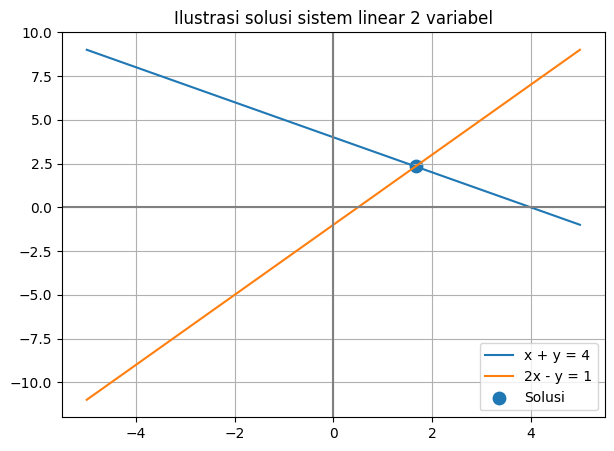

In [31]:
# Visualisasi dua garis dengan solusi unik
x_vals = np.linspace(-5, 5, 200)

# x + y = 4  -> y = 4 - x
y1 = 4 - x_vals

# 2x - y = 1 -> y = 2x - 1
y2 = 2*x_vals - 1

plt.figure(figsize=(7,5))
plt.plot(x_vals, y1, label='x + y = 4')
plt.plot(x_vals, y2, label='2x - y = 1')

# titik solusi
# x + y = 4
# 2x - y = 1
# 3x = 5 => x = 5/3
# y = 4 - 5/3 = 7/3
xs, ys = 5/3, 7/3
plt.scatter(xs, ys, s=80, label='Solusi')

plt.axhline(0, color='gray')
plt.axvline(0, color='gray')
plt.grid(True)
plt.legend()
plt.title("Ilustrasi solusi sistem linear 2 variabel")
plt.show()

# 23. Mini eksperimen: cek LU secara manual pada matriks lain

Kita coba matriks baru dan lihat apakah ide eliminasi Gauss → L dan U tetap berlaku.

In [32]:
A2 = np.array([
    [4., 3.],
    [6., 3.]
])

print("A2 =")
print(A2)

# Eliminasi manual
U2 = A2.copy()
m21 = U2[1,0] / U2[0,0]
U2[1] = U2[1] - m21 * U2[0]

L2 = np.array([
    [1., 0.],
    [m21, 1.]
])

print("\nL2 =")
print(L2)

print("\nU2 =")
print(U2)

print("\nL2 @ U2 =")
print(L2 @ U2)

print("\nApakah sama dengan A2?")
print(np.allclose(L2 @ U2, A2))

A2 =
[[4. 3.]
 [6. 3.]]

L2 =
[[1.  0. ]
 [1.5 1. ]]

U2 =
[[ 4.   3. ]
 [ 0.  -1.5]]

L2 @ U2 =
[[4. 3.]
 [6. 3.]]

Apakah sama dengan A2?
True


# 24. Analisis hasil chapter

Dari seluruh eksperimen pada chapter ini, kita bisa menarik beberapa poin penting:

## A. Row reduction adalah alat utama untuk menyelesaikan sistem linear
Dengan operasi baris elementer, kita dapat mengubah sistem ke bentuk yang lebih sederhana:
- REF
- RREF

## B. Pivot menentukan struktur solusi
Pivot membantu kita mengetahui:
- rank matriks
- jumlah variabel independen
- apakah sistem punya solusi unik, tak hingga, atau tidak ada solusi

## C. Gaussian elimination dan back substitution adalah prosedur inti
Untuk sistem dengan solusi unik, eliminasi Gauss mengubah sistem ke bentuk segitiga atas, lalu back substitution menghasilkan solusi.

## D. LU decomposition menyimpan proses eliminasi dalam bentuk matriks
Jika:
\[
A = LU
\]

maka:
- \(L\) menyimpan multiplier eliminasi
- \(U\) adalah hasil akhir eliminasi Gauss

## E. LU decomposition sangat efisien untuk banyak sistem dengan matriks yang sama
Jika kita perlu menyelesaikan banyak persamaan dengan matriks \(A\) yang sama tetapi vektor \(b\) berbeda, LU jauh lebih efisien.

# Kesimpulan Chapter 10

Pada chapter ini kita mempelajari **Row Reduction and LU Decomposition**, dua teknik fundamental dalam aljabar linear dan komputasi numerik.

## Ringkasan poin utama:
1. row reduction menggunakan operasi baris elementer untuk menyederhanakan matriks
2. Gaussian elimination mengubah matriks ke bentuk upper triangular / row echelon form
3. back substitution digunakan untuk memperoleh solusi sistem linear
4. RREF memungkinkan solusi dibaca langsung dari augmented matrix
5. jumlah pivot menentukan rank matriks
6. matriks singular memiliki rank tidak penuh dan tidak memiliki invers
7. LU decomposition memfaktorkan matriks menjadi:
   \[
   A = LU
   \]
8. matriks \(L\) menyimpan multiplier eliminasi, sedangkan \(U\) adalah hasil eliminasi
9. LU decomposition sangat berguna untuk efisiensi penyelesaian sistem linear berulang

## Relevansi ke machine learning dan deep learning
Konsep pada chapter ini sangat penting untuk:
- linear regression
- least squares
- optimisasi numerik
- matrix factorization
- scientific computing
- komputasi stabil dan efisien pada dataset besar

Chapter ini menjadi fondasi untuk chapter berikutnya:
- **General Linear Models and Least Squares**
- **Least Squares Applications**
- **Eigendecomposition**
- **Singular Value Decomposition**